In [1]:
import numpy as np
import xarray as xr
import pandas as pd
from scipy.stats import moment
from scipy import stats
import matplotlib.colors as mcolors

from scipy.stats import linregress
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score


import matplotlib.pyplot as plt
import calendar
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.cm import ScalarMappable


from pylab import rcParams
rcParams['axes.labelweight'] = 'bold'
rcParams['axes.labelsize'] = 'x-large'
rcParams['axes.titlesize'] = 'xx-large'
rcParams['axes.titleweight'] = 'bold'

In [2]:
def decode_time(filepath):
    ds = xr.open_dataset(filepath, decode_times=False)
    units, reference_date = ds.time.attrs['units'].split('since')
    ds['time'] = pd.date_range(start=reference_date, periods=ds.sizes['time'], freq='MS')
    return ds


# Define constants
p0 = 1000  # reference pressure in hPa
R = 287.05  # specific gas constant for dry air in J/(kg*K)
cp = 1005  # specific heat at constant pressure for dry air in J/(kg*K)

def convert_to_potential_temperature(T, p):
    """
    Convert temperature to potential temperature.
    
    Parameters:
    T (xarray.DataArray): Temperature in K
    p (xarray.DataArray): Pressure in hPa
    
    Returns:
    xarray.DataArray: Potential temperature in K
    """
    return T * (p0 / p) ** (R / cp)


In [3]:

def detrend_yearly_limited(s, start_year=1991, end_year=2020):
    # Extract years and values
    years = s.year.values
    values = s.values

    # Filter the data for the specified range (1990-2020)
    mask = (years >= start_year) & (years <= end_year)
    years_subset = years[mask]
    values_subset = values[mask]

    # Fit a linear trend to the subset of data
    slope, intercept, _, _, _ = stats.linregress(years_subset, values_subset)

    # Compute the trend based on the entire time span using the calculated slope and intercept
    trend = slope * years + intercept

    # Detrend the data
    detrended_values = values - trend

    # Create a new DataArray for the detrended data
    detrended_data = xr.DataArray(
        detrended_values,
        coords={"year": years},
        dims="year"
    )
    return detrended_data


In [4]:

from statsmodels.nonparametric.smoothers_lowess import lowess

def detrend_yearly_loess_full(s, frac=0.6):
    """
    Detrend a full time series using LOESS smoothing.
    
    Parameters:
        s (xr.DataArray): Input data with a 'year' coordinate.
        frac (float): Fraction of data used for LOESS smoothing (controls smoothness).
    
    Returns:
        xr.DataArray: Detrended data array.
    """
    # Extract years and values
    years = s.year.values
    values = s.values

    # Apply LOESS smoothing to the full dataset
    loess_fit = lowess(values, years, frac=frac, return_sorted=False)
    
    plt.plot(loess_fit)
    plt.plot(values)
    

    # Detrend the data
    detrended_values = values - loess_fit

    # Create a new DataArray for the detrended data
    detrended_data = xr.DataArray(
        detrended_values,
        coords={"year": years},
        dims="year"
    )
    return detrended_data


In [5]:
def plot_with_regression(ax, x, y, nino34, x_label):
    # Reshape for sklearn (requires 2D array for features)
    x_reshaped = x.reshape(-1, 1)

    # Regression
    model = LinearRegression()
    model.fit(x_reshaped, y)
    y_pred = model.predict(x_reshaped)
    r2 = r2_score(y, y_pred)

    # Scatter plot
    scatter = ax.scatter(x, y, c=nino34, cmap='coolwarm', vmin=-1, vmax=1, edgecolor='w', s=40)
    
    #highlight 2023
    scatter = ax.scatter(x[-1:], y[-1:], c=nino34[-1:], cmap='coolwarm', vmin=-1, vmax=1, edgecolor='k', s=40)
    
    
    # Regression line
    ax.plot(np.sort(x), np.sort(y_pred), color='black', linestyle='--', label=f'$R^2 = {r2:.2f}$')
    
    # Dashed lines at zero
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.7)
    ax.axvline(0, color='gray', linestyle='--', linewidth=0.7)

    # Only display horizontal grid lines and remove the plot frame
    ax.yaxis.grid(False)  # Horizontal grid lines
    ax.xaxis.grid(False)  # No vertical grid lines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    
    # Labels and title
    ax.set_xlabel(x_label)
    ax.set_ylabel(r'$T_{500} (det_limrended)$')
    
    ax.legend()
    
    #compute residuals
    residuals = y-y_pred

    return scatter, residuals


# T500

In [78]:
fp = '/data/jmex/ERA5/monthly/era5_t500.nc'
t500 = decode_time(fp).sel(time = slice('1979', '2023'), lat = slice(25, -15)).sel(plev = 50000)
weights = np.cos(np.deg2rad(t500.lat))

t500['ocean_mean'] = t500.t.weighted(weights).mean(['lat', 'lon'])

In [79]:
#ASO season
t500_aso = t500.where(t500.time.dt.month.isin([8,9,10])).groupby('time.year').mean()

clim = t500_aso.sel(year = slice('1991', '2020')).ocean_mean.mean('year')

#ASO anom
t500_aso['ocean_anom'] = t500_aso.ocean_mean - clim

In [80]:
t500_aso['det'] = detrend_yearly_limited(t500_aso.ocean_anom)

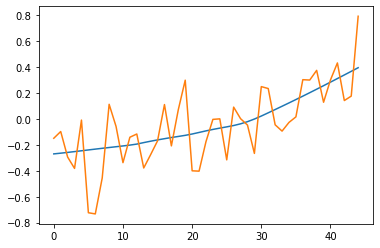

In [81]:
t500_aso['det'] = detrend_yearly_loess_full(t500_aso.ocean_anom)


###  Ocean Mask

In [127]:
#load the masks
fp = '/data/jmex/masks/RECCAP2_region_masks_all.nc'
masks = xr.open_dataset(fp).sel(lat = slice(-15,25))
ocean_mask = masks.open_ocean.isin([2,3]) # mask for tropical indo-pacifi

## SST

In [128]:
#import sst
fp = '/data/jmex/ERA5/monthly/era5_sst.nc'
sst = decode_time(fp).sel(lat = slice(25,-15), time = slice('1979', '2023'))
#ocean_mask = ~sst.isel(time = 1).sst.isnull()
sst = sst.where(ocean_mask)

In [129]:
sst_aso = sst.where(sst.time.dt.month.isin([8,9,10])).groupby('time.year').mean()

In [130]:
# compute nino34 for aso 
nino34 = sst_aso.sel(lat = slice(5, -5), lon = slice(190, 240))
nino34 = nino34 - nino34.sel(year = slice('1991', '2020')).mean('year')
nino34 = nino34.weighted(np.cos(np.deg2rad(nino34.lat))).mean(['lat', 'lon'])
#nino34 = nino34-nino34.mean()

## TP

In [144]:
fp = '/data/jmex/ERA5/monthly/era5_tp.nc'
tp = decode_time(fp).sel(lat = slice(25,-15), time = slice('1979','2023'))

#tp aso only 

tp_aso = tp.where(tp.time.dt.month.isin([8,9,10])).groupby('time.year').mean()

In [145]:


#take t for ocean mask only: 
tp_aso = tp_aso.where(ocean_mask)

weights = np.cos(np.deg2rad(tp.lat))
tp_aso['ocean_mean'] = tp_aso.tp.weighted(weights).mean(['lat', 'lon'])

## PWS

In [146]:
pws_aso = xr.zeros_like(sst_aso)
pws_aso = pws_aso.rename({'sst': 'pws'})

In [147]:
pws_aso['pws'] = sst_aso.sst * tp_aso.tp/tp_aso.ocean_mean 
pws_aso['pws_mean'] = pws_aso.pws.weighted(weights).mean(['lat', 'lon'])
#subtract mean
pws_aso['pws_mean'] = pws_aso['pws_mean']-pws_aso.pws_mean.mean()

In [148]:
pws_aso['pws_detrended'] = detrend_yearly_limited(pws_aso.pws_mean)

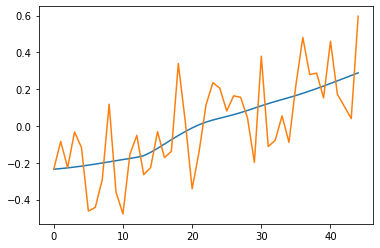

In [149]:
pws_aso['pws_detrended'] = detrend_yearly_loess_full(pws_aso.pws_mean)

## Sobel


In [92]:
# make sst into anoms
sst_aso['anom'] = sst_aso.sst - sst_aso.sst.sel(year = slice('1991', '2023')).mean('year')

In [93]:
P_0 = 6

In [94]:
sst_p = xr.zeros_like(sst_aso)
sst_p = sst_p.rename({'sst': 'sst_p'})
sst_p['sst_p']= sst_aso.anom.where(tp_aso.tp>=P_0).weighted(weights).mean(['lat', 'lon'])

In [95]:
sst_p['det'] = detrend_yearly_limited(sst_p.sst_p)

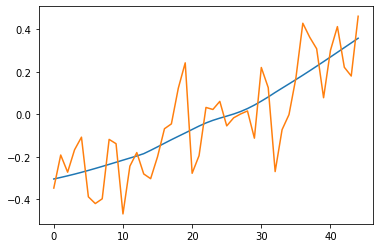

In [96]:
sst_p['det'] = detrend_yearly_loess_full(sst_p.sst_p)

In [97]:
#import sst full data for residual plotting
fp = '/data/jmex/ERA5/monthly/era5_sst.nc'
sst_full = decode_time(fp).sel(lat = slice(60,-60), time = slice('1979', '2023'))

sst_full_aso = sst_full.where(sst_full.time.dt.month.isin([8,9,10])).groupby('time.year').mean()

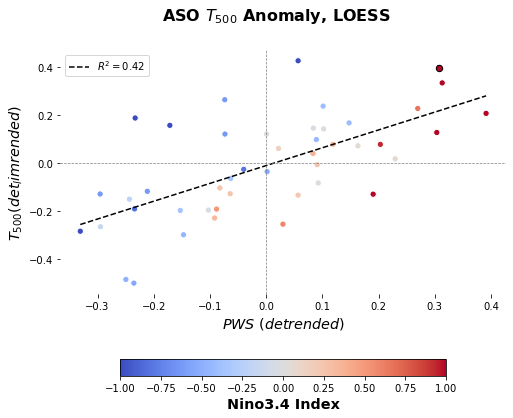

In [150]:
# Custom colormap for nino34 categories
from matplotlib.colors import ListedColormap, BoundaryNorm
colors = ['darkblue', 'blue', 'white', 'red', 'darkred']
bounds = [-1.5, -1, -0.5, 0.5, 1, 1.5]
cmap = ListedColormap(colors)
norm = BoundaryNorm(bounds, cmap.N)

# Create figure with two subplots
fig, axes = plt.subplots(1, 1, figsize=(8, 6), sharey=True)


# Plot 2
scatter2, residuals = plot_with_regression(axes, pws_aso.pws_detrended.values, t500_aso.det, nino34.sst, x_label = r'$PWS \ (detrended)$')

# Set ticks to match the meaningful intervals only
cbar = fig.colorbar(scatter2, ax=axes, orientation='horizontal', fraction=0.05, pad=0.2)#, ticks=[-1.5, 1, 0, 1, 1.5])
cbar.set_label('Nino3.4 Index')
#cbar.ax.set_xticklabels(['Strong La Niña', 'La Niña', 'Neutral', 'El Niño', 'Strong El Niño'])

fig.suptitle(r"ASO $T_{500}$ Anomaly, LOESS", fontsize = 16, fontweight = 'bold')


# Adjust layout
#plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Res of PWS, LOESS, ERA5')

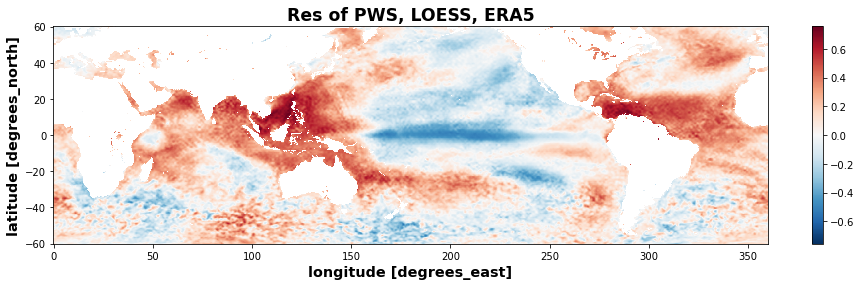

In [185]:
xr.corr(residuals, sst_full_aso.sst, dim = 'year').plot(size = 4, aspect = 4)
plt.title('Res of PWS, LOESS, ERA5')

In [ ]:
from scipy.stats import pearsonr

# Assuming residuals and sst_full_aso.sst are already defined
def calc_corr_and_pval(residuals, sst, dim='year'):
    def corr_and_pval(x, y):
        mask = ~np.isnan(x) & ~np.isnan(y)  # Handle NaNs
        if mask.sum() < 2:  # Not enough data points
            return np.nan, np.nan
        r, p = pearsonr(x[mask], y[mask])
        return r, p
    
    return xr.apply_ufunc(
        corr_and_pval, 
        residuals, 
        sst,
        input_core_dims=[[dim], [dim]],
        output_core_dims=[[], []],
        vectorize=True,
        dask="parallelized",
        output_dtypes=[float, float],
    )

# Calculate correlation and p-values
corr, pval = calc_corr_and_pval(residuals, sst_full_aso.sst)

<Figure size 576x576 with 0 Axes>

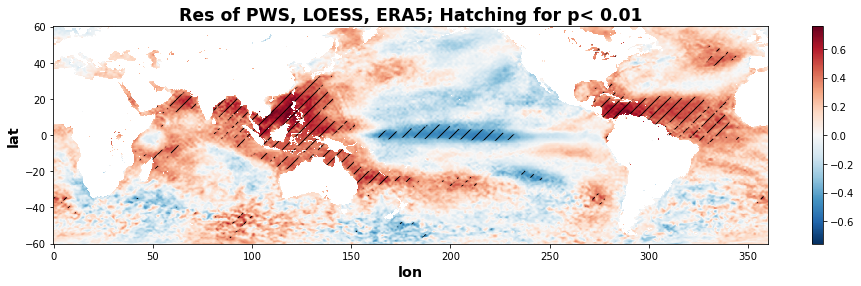

In [191]:
# Plot correlation
plt.figure(figsize=(8, 8))
corr.plot(size=4, aspect=4)
plt.title('Res of PWS, LOESS, ERA5')

# Create a mask for significant regions (p < 0.05)
sig_mask = pval < 0.01

# Add diagonal hatching for significant regions
plt.contourf(
    corr.lon, corr.lat, sig_mask,  # Coordinates and mask
    levels=[0.5, 1.5],  # Define binary levels
    colors='none',  # No filled color
    hatches=['//'],  # Diagonal hatching
    extend='neither',
    alpha=0  # Fully transparent background, only hatching visible
)

# Add legend if needed
plt.title('Res of PWS, LOESS, ERA5; Hatching for p< 0.01')
plt.show()

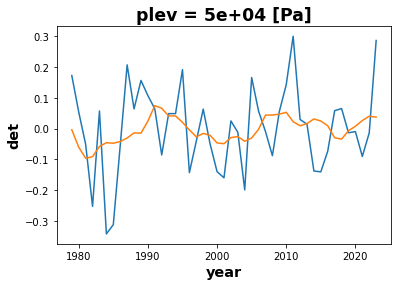

In [200]:
residuals.plot()
residuals.rolling(year = 10, center = True, min_periods = 1).mean().plot()

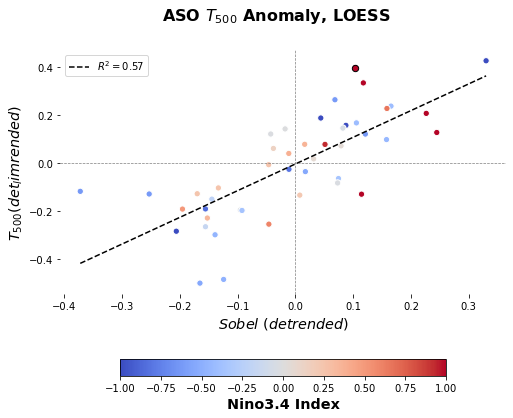

In [199]:
# Custom colormap for nino34 categories
from matplotlib.colors import ListedColormap, BoundaryNorm
colors = ['darkblue', 'blue', 'white', 'red', 'darkred']
bounds = [-1.5, -1, -0.5, 0.5, 1, 1.5]
cmap = ListedColormap(colors)
norm = BoundaryNorm(bounds, cmap.N)

# Create figure with two subplots
fig, axes = plt.subplots(1, 1, figsize=(8, 6), sharey=True)


# Plot 2
scatter2, residuals = plot_with_regression(axes, sst_p.det.values, t500_aso.det, nino34.sst, x_label = r'$Sobel \ (detrended)$')

# Set ticks to match the meaningful intervals only
cbar = fig.colorbar(scatter2, ax=axes, orientation='horizontal', fraction=0.05, pad=0.2)#, ticks=[-1.5, 1, 0, 1, 1.5])
cbar.set_label('Nino3.4 Index')
#cbar.ax.set_xticklabels(['Strong La Niña', 'La Niña', 'Neutral', 'El Niño', 'Strong El Niño'])

fig.suptitle(r"ASO $T_{500}$ Anomaly, LOESS", fontsize = 16, fontweight = 'bold')


# Adjust layout
#plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Res of Sobel, LOESS')

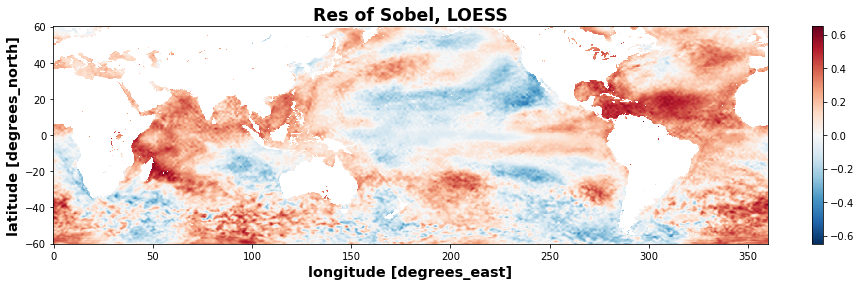

In [101]:
xr.corr(residuals, sst_full_aso.sst, dim = 'year').plot(size = 4, aspect = 4)
plt.title('Res of Sobel, LOESS')

In [108]:
## import GPCP to be able to compare

In [109]:
fp = '/data/jmex/NOAA/precip.mon.mean.nc'
tp = xr.open_dataset(fp).sel(lat = slice(-15,25), time = slice(None,'2023'))
tp = tp.drop_vars(['time_bnds', 'lat_bnds', 'lon_bnds']).rename({'precip':'tp'})

#tp aso_gpcp only 

tp_aso_gpcp = tp.where(tp.time.dt.month.isin([8,9,10])).groupby('time.year').mean()

In [111]:
#interp sst to match gpcp
sst_aso = sst_aso.interp(lat = tp.lat, lon = tp.lon, method = 'nearest')

#second ocean_mask, on the GPCP grid
#make ocean mask
ocean_mask2 = ~sst_aso.isel(year = 1).sst.isnull()


#take t for ocean mask only: 
tp_aso_gpcp = tp_aso_gpcp.where(ocean_mask2)

weights = np.cos(np.deg2rad(tp.lat))
tp_aso_gpcp['ocean_mean'] = tp_aso_gpcp.tp.weighted(weights).mean(['lat', 'lon'])

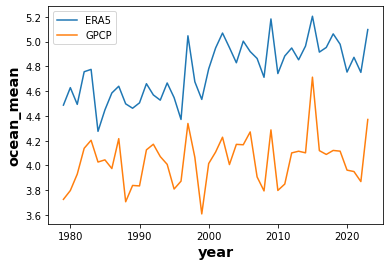

In [142]:
tp_aso.ocean_mean.plot(label = 'ERA5')
tp_aso_gpcp.ocean_mean.plot(label = 'GPCP')
plt.legend()

## PWS

In [112]:
pws_aso_gpcp = xr.zeros_like(sst_aso)
pws_aso_gpcp = pws_aso_gpcp.rename({'sst': 'pws'})

In [113]:
pws_aso_gpcp['pws'] = sst_aso.sst * tp_aso_gpcp.tp/tp_aso_gpcp.ocean_mean 
pws_aso_gpcp['pws_mean'] = pws_aso_gpcp.pws.weighted(weights).mean(['lat', 'lon'])
#subtract mean
pws_aso_gpcp['pws_mean'] = pws_aso_gpcp['pws_mean']-pws_aso_gpcp.pws_mean.mean()

In [114]:
pws_aso_gpcp['pws_detrended'] = detrend_yearly_limited(pws_aso_gpcp.pws_mean)

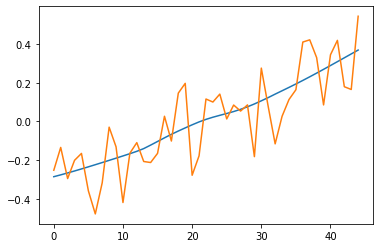

In [115]:
pws_aso_gpcp['pws_detrended'] = detrend_yearly_loess_full(pws_aso_gpcp.pws_mean)

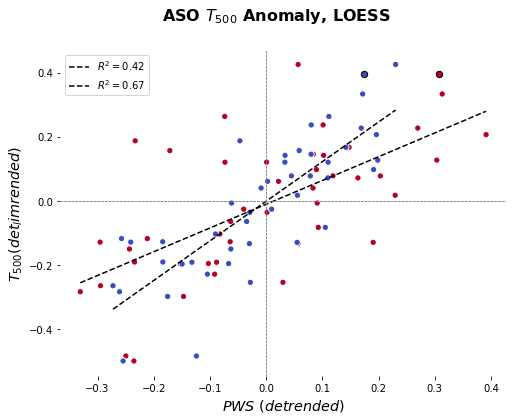

In [137]:
# Custom colormap for nino34 categories
from matplotlib.colors import ListedColormap, BoundaryNorm
colors = ['darkblue', 'blue', 'white', 'red', 'darkred']
bounds = [-1.5, -1, -0.5, 0.5, 1, 1.5]
cmap = ListedColormap(colors)
norm = BoundaryNorm(bounds, cmap.N)

# Create figure with two subplots
fig, axes = plt.subplots(1, 1, figsize=(8, 6), sharey=True)


# Plot 2
scatter2, residuals = plot_with_regression(axes, pws_aso.pws_detrended.values, t500_aso.det, np.ones(45), x_label = r'$PWS \ (detrended)$')
scatter2, residuals = plot_with_regression(axes, pws_aso_gpcp.pws_detrended.values, t500_aso.det, -np.ones(45), x_label = r'$PWS \ (detrended)$')


fig.suptitle(r"ASO $T_{500}$ Anomaly, LOESS", fontsize = 16, fontweight = 'bold')


# Adjust layout
#plt.tight_layout()
plt.show()